<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_10_SBIBM_Hybrid_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercise 10 — A high-precision hNPE–hNDE benchmark on sbibm

Exercises 5–9 established the hybrid constructions on controlled examples. This exercise is an independent benchmark implementation: none of their algorithms or helper functions is modified.

Version 2 implements the predeclared “winning strategy”:

- a correctly mixed neural spline flow, with learned LU mixing after every coupling transform;
- a small all-data NSF baseline matching the architecture scale used by the published NPE;
- genuine fivefold cross-fitting, so every simulation trains a ratio exactly once and a flow four times;
- one large, four-member posterior correction ensemble in every fold;
- an equally large, four-member hNDE likelihood-ratio ensemble in every fold;
- plateau learning-rate schedules, fresh checkpoints, and diagnostics selected without reference posterior samples;
- full C2ST comparisons for the NPE reference, hNPE, hNDE, and the dual consensus;
- explicit campaigns for both Two Moons and SLCP.

The simulator budget remains exactly 100,000 unique prior-predictive pairs per task. Cross-fitting and ensembling spend computation, not additional simulator calls.


In [1]:
## ============================================================================
# Google Colab setup — safe to re-run and a no-op off Colab.
# ============================================================================
import os, sys
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
USE_DRIVE = True


def run(*args, env=None):
    subprocess.run([str(arg) for arg in args], check=True, env=env)


IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive

        drive.mount("/content/drive")
        ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab")
    else:
        ROOT = Path("/content")
    ROOT.mkdir(parents=True, exist_ok=True)

    REPO_DIR = ROOT / "nsbi-lhc-toolkit"
    TUTORIAL_DIR = REPO_DIR / "workshops" / "ml4hep_tifr_colab"
    # This backward-compatible working directory preserves models from Exercises 4--9.
    WORK_DIR = REPO_DIR / "workshops" / "ml4hep_tifr"
    if not (REPO_DIR / ".git").is_dir():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, REPO_DIR, env=clone_env,
        )
    else:
        run("git", "-C", REPO_DIR, "remote", "set-url", "origin", REPO_URL)
        run("git", "-C", REPO_DIR, "fetch", "origin", BRANCH)
        run("git", "-C", REPO_DIR, "checkout", BRANCH)
        run("git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH)
    run(
        "git", "-C", REPO_DIR, "sparse-checkout", "set",
        "src", "workshops/ml4hep_tifr_colab",
    )
    for import_dir in (REPO_DIR / "src", TUTORIAL_DIR):
        import_path = str(import_dir.resolve())
        if import_path not in sys.path:
            sys.path.insert(0, import_path)

    # Colab already provides PyTorch, NumPy, SciPy, pandas, and scikit-learn.
    # Installing sbibm without its historical algorithm dependencies avoids
    # downgrading the modern Colab environment; only the task/metric dependencies
    # used below are added explicitly. Version 1.1.0 is the latest official
    # sbibm release and includes the corrected Gaussian Mixture simulator.
    run(sys.executable, "-m", "pip", "install", "-q", "nflows", "pyro-ppl")
    run(
        sys.executable, "-m", "pip", "install", "-q", "--no-deps",
        "sbibm==1.1.0",
    )
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(WORK_DIR)
else:
    for candidate in [
        Path.cwd(),
        Path.cwd() / "workshops" / "ml4hep_tifr_colab",
    ]:
        if (candidate / "utils_benchmark.py").exists():
            sys.path.insert(0, str(candidate.resolve()))
            break

print("Working directory:", Path.cwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr


In [2]:
import gc
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sbibm
import torch
from IPython.display import display

from utils_benchmark import (
    PAPER_ALGORITHMS,
    best_published_targets,
    compare_with_paper,
    crossfit_coverage_table,
    draw_hybrid_posterior,
    evaluate_observation_suite,
    evaluate_posterior_samples,
    load_or_simulate_bank,
    load_paper_results,
    posterior_predictive_diagnostics,
    simulation_based_calibration_diagnostics,
    summarize_our_results,
    summarize_paper_results,
    task_recommendation_table,
    train_hybrid_benchmark_model,
    train_official_style_nsf_baseline,
    training_diagnostics,
)
from utils_plotting import export_standalone_figure_script

SEED = 23102026
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("sbibm version:", sbibm.__version__)
print("Using device:", device)


sbibm version: 1.1.0
Using device: cuda


## 1. What is in the benchmark?

The paper defines ten tasks from eight simulator families. This campaign focuses on two continuous tasks for which both hybrid paths are well defined:

- **Two Moons** has a curved, multimodal two-dimensional posterior and directly exposes whether a flow mixes both parameter coordinates.
- **SLCP** has five parameters, eight observables, and a four-mode posterior. It is a substantially harder test of both the conditional posterior and the generative hNDE route.

The remaining tasks stay in the recommendation table for later campaigns. The discrete and ODE tasks require additional modeling choices and are not silently forced through a continuous hNDE.


In [3]:
recommendations = task_recommendation_table()
display(
    recommendations[
        [
            "task", "dim_parameters", "dim_data", "data_type",
            "recommended_method", "colab_status", "reason",
        ]
    ].style.hide(axis="index")
)


task,dim_parameters,dim_data,data_type,recommended_method,colab_status,reason
gaussian_linear,10,10,continuous,dual hNPE--hNDE,ready,A normalization and scaling control; the posterior is nearly solved.
gaussian_linear_uniform,10,10,"continuous, bounded parameters",dual hNPE--hNDE,ready,Tests exact bounded support through the parameter logit transform.
gaussian_mixture,2,2,continuous mixture,dual hNPE--hNDE,ready,A compact heavy-tail test; corrected v1.1 benchmark results are used.
two_moons,2,2,"continuous, multimodal",dual hNPE--hNDE,primary target,The paper's diagnostic example has curved modes and clear headroom.
slcp,5,8,"continuous, four-mode posterior",dual hNPE--hNDE,stretch target,The best published mean C2ST at 100k is still far from 0.5.
slcp_distractors,5,100,continuous with 92 distractors,hNPE; optional dual,expensive,hNPE avoids making a 100-dimensional observation flow the bottleneck.
bernoulli_glm,10,10,discrete-derived sufficient statistics,hNPE,ready,A conditional posterior can use the summaries directly; a continuous hNDE reference is not an exact probability-mass model.
bernoulli_glm_raw,10,100,binary,hNPE,expensive,The raw observation is discrete and 100-dimensional.
sir,2,10,count time series,hNPE,Julia backend required,The official simulator uses diffeqtorch/Julia; hNDE would need a discrete or dequantized reference model.
lotka_volterra,4,20,count time series,hNPE,Julia backend required,The official simulator uses diffeqtorch/Julia and is costly.


## 2. The two hybrid factorizations and the cross-fit

Forward pairs are sampled once from the prior predictive distribution,

$$
(	\theta_i,x_i)sim pi(	heta)p(xmid	heta).
$$

For fold $k$, four fifths of the bank train the conditional reference
$$
q_{\phi,k}(	\theta\mid x),
$$
and the held-out fifth trains one posterior correction

$$
r_{{
mP},k}(	\theta,x)
=
\frac{p(	\theta\mid x)}
     {(1-\epsilon)q_{\phi,k}(	\theta\mid x)+\epsilon \pi(	\theta)}.
$$
The five corrected posteriors are mixed with equal fold weights. Multiplying repeated estimates of the same ratio would double-count the correction, so only one correction is applied in each fold.

The independent hNDE path trains
[
q_{eta,k}(x),qquad
r_{{
m L},k}(x;	heta)=rac{p(xmid	heta)}{q_{eta,k}(x)}.
]
It reconstructs the posterior through (pi(	heta)r_{{
m L},k}(x_o;	heta)). The hNDE networks and ensembles have the same precision settings as hNPE; hNDE and the fixed dual consensus remain explicit benchmark entries rather than being discarded when they are difficult.


## 3. What has to be beaten?

The paper evaluates 10,000 inferred posterior samples against 10,000 reference samples with a z-scored, five-fold neural classifier two-sample test. C2ST $=0.5$ is ideal and lower is better. Results are averaged over ten fixed observations, with simulation budgets of $10^3$, $10^4$, and $10^5$ **per trained inference model**.

The official Gaussian Mixture simulator had a bug that was corrected in `sbibm` v1.1.0. Exercise 10 uses the official rerun table for that task and the manuscript table for the other nine tasks.


In [4]:
paper_results = load_paper_results(corrected_gaussian_mixture=True)
targets_100k = best_published_targets(paper_results, num_simulations=100_000)
display(
    targets_100k[
        ["task", "algorithm", "mean", "ci95"]
    ].rename(
        columns={
            "algorithm": "best published algorithm",
            "mean": "mean C2ST",
            "ci95": "95% CI",
        }
    ).style.format({"mean C2ST": "{:.4f}", "95% CI": "{:.4f}"}).hide(axis="index")
)


task,best published algorithm,mean C2ST,95% CI
bernoulli_glm,SNLE,0.5218,0.0078
bernoulli_glm_raw,SNRE,0.5525,0.0091
gaussian_linear,NPE,0.5060,0.0025
gaussian_linear_uniform,NLE,0.5065,0.0027
gaussian_mixture,SNRE,0.5310,0.0110
lotka_volterra,SNLE,0.6951,0.0635
sir,SNRE,0.5472,0.0162
slcp,SNLE,0.5781,0.0182
slcp_distractors,SNRE,0.7662,0.0318
two_moons,SNPE,0.5298,0.0159


## 4. Choose the campaign

The profiles control computation but never change the simulator accounting. The paper and challenge profiles use five complementary folds and four large ratio networks per fold, for both hNPE and hNDE.

Run the notebook first with Two Moons. Then change only TASK_NAME to SLCP and rerun; the final campaign cell combines the two saved v2 result files.


In [5]:
PROFILE = "challenge"  # "quick", "paper", or "challenge"
TASK_NAME = "slcp"  # First run "two_moons"; then rerun with "slcp".
BENCHMARK_TASKS = ("two_moons", "slcp")
LOAD_IF_AVAILABLE = False
RUN_SBC = True
RUN_POSTERIOR_PREDICTIVE = False  # Adds calls outside the official 100k budget.

if TASK_NAME not in BENCHMARK_TASKS:
    raise ValueError(f"TASK_NAME must be one of {BENCHMARK_TASKS}.")

PROFILES = {
    "quick": {
        "num_simulations": 10_000,
        "num_folds": 2,
        "ensemble_size": 2,
        "flow_epochs": 25,
        "baseline_epochs": 25,
        "ratio_epochs": 35,
        "n_proposal": 60_000,
        "observations": [1],
        "sbc_cases_per_fold": 8,
        "sbc_proposal": 256,
    },
    "paper": {
        "num_simulations": 100_000,
        "num_folds": 5,
        "ensemble_size": 4,
        "flow_epochs": 70,
        "baseline_epochs": 70,
        "ratio_epochs": 90,
        "n_proposal": 300_000,
        "observations": list(range(1, 11)),
        "sbc_cases_per_fold": 24,
        "sbc_proposal": 512,
    },
    "challenge": {
        "num_simulations": 100_000,
        "num_folds": 5,
        "ensemble_size": 4,
        "flow_epochs": 90,
        "baseline_epochs": 90,
        "ratio_epochs": 120,
        "n_proposal": 500_000,
        "observations": list(range(1, 11)),
        "sbc_cases_per_fold": 32,
        "sbc_proposal": 768,
    },
}
campaign = PROFILES[PROFILE]
NUM_SIMULATIONS = campaign["num_simulations"]
N_CROSSFIT_FOLDS = campaign["num_folds"]
RATIO_ENSEMBLE_SIZE = campaign["ensemble_size"]
N_PROPOSAL = campaign["n_proposal"]
OBSERVATIONS = campaign["observations"]
N_POSTERIOR_SAMPLES = 10_000
DEFENSIVE_EPSILON = 0.02
SPLIT_SEED = SEED + 17
TRAIN_HNDE = True
HEADLINE_METHOD = "hNPE"

# High-capacity references for the hybrid folds. The ratio correction below
# deliberately remains as large as v1, as requested.
FLOW_MODEL_CONFIG = {
    "n_coupling_layers": 8,
    "hidden_features": 256,
    "hidden_layers": 3,
    "spline_num_bins": 16,
    "spline_tail_bound": 5.0,
    "dropout_probability": 0.0,
}
FLOW_TRAINING_CONFIG = {
    "batch_size": 1024,
    "n_epochs": campaign["flow_epochs"],
    "learning_rate": 1.0e-3,
    "lr_scheduler_factor": 0.3,
    "lr_scheduler_patience": 4,
    "min_learning_rate": 1.0e-6,
    "validation_fraction": 0.1,
    "patience": 18,
    "gradient_clip": 5.0,
}

# A separate all-data baseline matching the published NSF scale.
BASELINE_MODEL_CONFIG = {
    "n_coupling_layers": 5,
    "hidden_features": 50,
    "hidden_layers": 2,
    "spline_num_bins": 10,
    "spline_tail_bound": 3.0,
    "dropout_probability": 0.0,
}
BASELINE_TRAINING_CONFIG = {
    **FLOW_TRAINING_CONFIG,
    "n_epochs": campaign["baseline_epochs"],
    "patience": 15,
}

RATIO_MODEL_CONFIG = {
    "hidden_features": 1024,
    "hidden_layers": 5,
    "dropout_probability": 0.0,
}
RATIO_TRAINING_CONFIG = {
    "batch_size": 2048,
    "n_epochs": campaign["ratio_epochs"],
    "learning_rate": 1.0e-3,
    "lr_scheduler": "plateau",
    "lr_scheduler_factor": 0.3,
    "lr_scheduler_patience": 3,
    "min_learning_rate": 1.0e-6,
    "validation_fraction": 0.15,
    "patience": 25,
    "gradient_clip": 5.0,
}

RUN_TAG = (
    f"{PROFILE}_budget{NUM_SIMULATIONS}_lu8_k{N_CROSSFIT_FOLDS}_"
    f"ratioensemble{RATIO_ENSEMBLE_SIZE}_v2"
)
MODEL_DIR = Path("models_exercise10_sbibm") / TASK_NAME / RUN_TAG
CACHE_DIR = Path("dataframes_exercise10_sbibm")
RESULT_DIR = Path("exercise10_benchmark_results")
FIGURE_SCRIPT_DIR = Path("exercise10_figures_scripts") / TASK_NAME / RUN_TAG
for directory in (MODEL_DIR, CACHE_DIR, RESULT_DIR, FIGURE_SCRIPT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(json.dumps({
    "profile": PROFILE,
    "task": TASK_NAME,
    "campaign_tasks": BENCHMARK_TASKS,
    "simulator_budget": NUM_SIMULATIONS,
    "crossfit_folds": N_CROSSFIT_FOLDS,
    "ratio_members_per_fold_per_path": RATIO_ENSEMBLE_SIZE,
    "train_hnde": TRAIN_HNDE,
    "headline_method": HEADLINE_METHOD,
    "run_tag": RUN_TAG,
    "observations": OBSERVATIONS,
}, indent=2))


{
  "profile": "challenge",
  "task": "slcp",
  "campaign_tasks": [
    "two_moons",
    "slcp"
  ],
  "simulator_budget": 100000,
  "crossfit_folds": 5,
  "ratio_members_per_fold_per_path": 4,
  "train_hnde": true,
  "headline_method": "hNPE",
  "run_tag": "challenge_budget100000_lu8_k5_ratioensemble4_v2",
  "observations": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10
  ]
}


## 5. Acquire the exact-budget simulation bank

The official prior and simulator generate one cached bank per task and budget. The same bank is reused by the all-data NSF baseline, all five hNPE folds, and all five hNDE folds. The coverage check below fails immediately unless every row has exactly one ratio role and four flow roles in the fivefold campaign.


In [6]:
try:
    task = sbibm.get_task(TASK_NAME)
except (ImportError, ModuleNotFoundError) as exc:
    raise RuntimeError(f"Could not load the official sbibm task {TASK_NAME!r}.") from exc

print(
    f"{task.name_display}: dim(theta)={task.dim_parameters}, "
    f"dim(x)={task.dim_data}, observations={task.num_observations}"
)
simulation_bank = load_or_simulate_bank(
    task,
    NUM_SIMULATIONS,
    cache_path=CACHE_DIR / f"{TASK_NAME}_prior_predictive_{NUM_SIMULATIONS}_seed{SEED}.npz",
    seed=SEED,
    chunk_size=20_000,
)
assert simulation_bank.num_simulations == NUM_SIMULATIONS
print("Unique simulator calls used for every neural object:", simulation_bank.num_simulations)

coverage = crossfit_coverage_table(
    simulation_bank,
    n_folds=N_CROSSFIT_FOLDS,
    split_seed=SPLIT_SEED,
)
display(coverage.style.hide(axis="index"))


SLCP: dim(theta)=5, dim(x)=8, observations=10
Saved exactly 100,000 simulations to dataframes_exercise10_sbibm/slcp_prior_predictive_100000_seed23102026.npz
Unique simulator calls used for every neural object: 100000


fold,flow_rows,ratio_rows,overlap_rows,ratio_coverage_min,ratio_coverage_max,flow_coverage_min,flow_coverage_max
0,80000,20000,0,1,1,4,4
1,80000,20000,0,1,1,4,4
2,80000,20000,0,1,1,4,4
3,80000,20000,0,1,1,4,4
4,80000,20000,0,1,1,4,4


## 6. Train the all-data NSF and the fivefold hybrid model

The all-data baseline isolates the effect of fixing the flow architecture. Each hybrid fold then trains a high-capacity conditional reference and one large posterior-ratio ensemble. The dual route independently trains an LU-mixed observation reference and an equally large likelihood-ratio ensemble.

All checkpoints live under the v2 run tag. The defective v1 flows therefore cannot be loaded accidentally. No function used by Exercises 1–9 is changed.


In [7]:
baseline_model = train_official_style_nsf_baseline(
    task,
    simulation_bank,
    checkpoint=MODEL_DIR / "all_data_official_style_nsf.pt",
    model_config=BASELINE_MODEL_CONFIG,
    training_config=BASELINE_TRAINING_CONFIG,
    device=device,
    seed=SEED + 5_000,
    load_if_available=LOAD_IF_AVAILABLE,
)

hybrid_models = []
for fold in range(N_CROSSFIT_FOLDS):
    print("\n" + "=" * 88)
    print(f"TRAINING CROSSFIT FOLD {fold + 1}/{N_CROSSFIT_FOLDS}")
    print("=" * 88)
    hybrid_models.append(
        train_hybrid_benchmark_model(
            task,
            simulation_bank,
            model_dir=MODEL_DIR,
            flow_model_config=FLOW_MODEL_CONFIG,
            flow_training_config=FLOW_TRAINING_CONFIG,
            ratio_model_config=RATIO_MODEL_CONFIG,
            ratio_training_config=RATIO_TRAINING_CONFIG,
            device=device,
            seed=SEED + 100_000 * fold,
            split_seed=SPLIT_SEED,
            ensemble_size=RATIO_ENSEMBLE_SIZE,
            defensive_epsilon=DEFENSIVE_EPSILON,
            fold=fold,
            n_folds=N_CROSSFIT_FOLDS,
            train_hnde=TRAIN_HNDE,
            load_if_available=LOAD_IF_AVAILABLE,
            retrain_outliers=True,
        )
    )
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(
    f"Trained the all-data baseline and {len(hybrid_models)} hybrid folds; "
    f"unique simulator calls remain {NUM_SIMULATIONS:,}."
)


Training conditional LU-mixed spline flow on 90,000 rows
  epoch 001/90: lr=1.000e-03, train=6.6573, validation=6.0934
  epoch 002/90: lr=1.000e-03, train=5.0392, validation=4.2221
  epoch 003/90: lr=1.000e-03, train=3.7369, validation=3.4727
  epoch 004/90: lr=1.000e-03, train=3.2317, validation=3.0848
  epoch 005/90: lr=1.000e-03, train=2.9785, validation=2.8896
  epoch 006/90: lr=1.000e-03, train=2.8099, validation=2.8300
  epoch 007/90: lr=1.000e-03, train=2.6891, validation=2.6456
  epoch 008/90: lr=1.000e-03, train=2.6114, validation=2.5841
  epoch 009/90: lr=1.000e-03, train=2.5332, validation=2.5458
  epoch 010/90: lr=1.000e-03, train=2.4826, validation=2.4913
  epoch 011/90: lr=1.000e-03, train=2.4297, validation=2.4617
  epoch 012/90: lr=1.000e-03, train=2.3960, validation=2.4539
  epoch 013/90: lr=1.000e-03, train=2.3573, validation=2.3744
  epoch 014/90: lr=1.000e-03, train=2.3020, validation=2.2695
  epoch 015/90: lr=1.000e-03, train=2.2474, validation=2.4649
  epoch 016/9

/usr/local/lib/python3.12/dist-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2259.)
  outputs, _ = torch.triangular_solve(



Ratio ensemble member 1/4
Training balanced ratio classifier on 20,000 rows per class
  epoch 01/120: lr=1.000e-03, train=0.6943, validation=0.6935
  epoch 02/120: lr=1.000e-03, train=0.6932, validation=0.6940
  epoch 03/120: lr=1.000e-03, train=0.6931, validation=0.6932
  epoch 04/120: lr=1.000e-03, train=0.6931, validation=0.6935
  epoch 05/120: lr=1.000e-03, train=0.6931, validation=0.6936
  epoch 06/120: lr=1.000e-03, train=0.6929, validation=0.6940
  epoch 07/120: lr=1.000e-03, train=0.6927, validation=0.6948
  epoch 08/120: lr=3.000e-04, train=0.6925, validation=0.6938
  epoch 09/120: lr=3.000e-04, train=0.6922, validation=0.6937
  epoch 10/120: lr=3.000e-04, train=0.6921, validation=0.6937
  epoch 11/120: lr=3.000e-04, train=0.6918, validation=0.6933
  epoch 12/120: lr=9.000e-05, train=0.6916, validation=0.6937
  epoch 13/120: lr=9.000e-05, train=0.6912, validation=0.6947
  epoch 14/120: lr=9.000e-05, train=0.6912, validation=0.6946
  epoch 15/120: lr=9.000e-05, train=0.6911, v

Wrote standalone figure script: exercise10_figures_scripts/slcp/challenge_budget100000_lu8_k5_ratioensemble4_v2/training_histories_v2.py


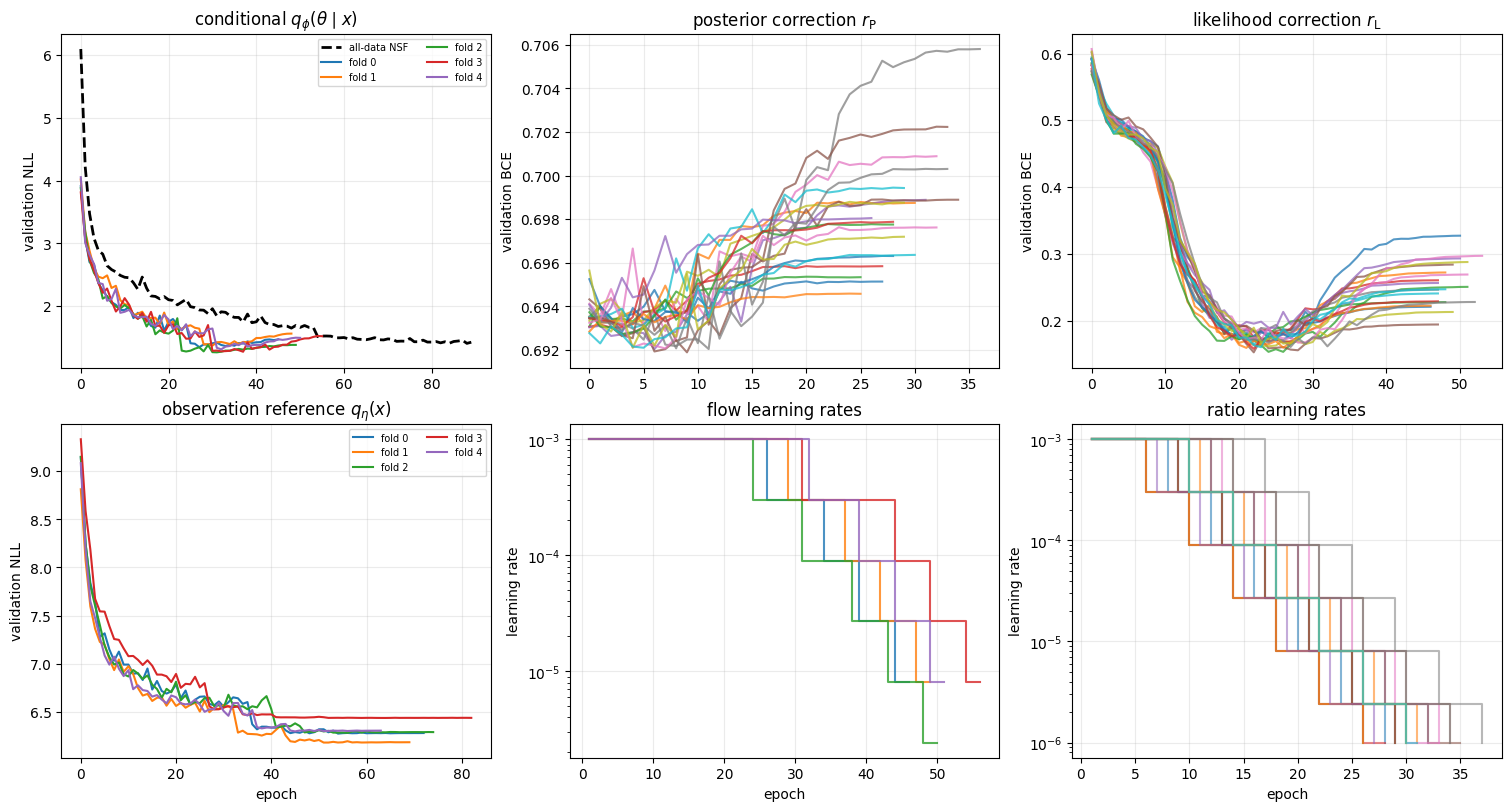

In [8]:
def export_exercise10_figure(fig, script_name):
    return export_standalone_figure_script(
        fig,
        script_name=script_name,
        output_dir=FIGURE_SCRIPT_DIR,
    )


fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axes[0, 0].plot(
    baseline_model.q_phi.get("history", {}).get("validation", []),
    color="black", ls="--", lw=2, label="all-data NSF",
)
for model in hybrid_models:
    fold_label = f"fold {model.fold}"
    q_phi_history = model.q_phi.get("history", {})
    axes[0, 0].plot(q_phi_history.get("validation", []), label=fold_label)
    axes[1, 1].step(
        np.arange(1, len(q_phi_history.get("learning_rate", [])) + 1),
        q_phi_history.get("learning_rate", []),
        where="post", alpha=0.8,
    )
    for member, pack in enumerate(model.r_p_ensemble):
        history = pack.get("history", {})
        axes[0, 1].plot(
            history.get("validation", []),
            alpha=0.75,
            label=f"{fold_label}, member {member}",
        )
        axes[1, 2].step(
            np.arange(1, len(history.get("learning_rate", [])) + 1),
            history.get("learning_rate", []),
            where="post", alpha=0.55,
        )
    if model.has_hnde:
        q_eta_history = model.q_eta.get("history", {})
        axes[1, 0].plot(q_eta_history.get("validation", []), label=fold_label)
        for member, pack in enumerate(model.r_l_ensemble):
            axes[0, 2].plot(
                pack.get("history", {}).get("validation", []),
                alpha=0.75,
                label=f"{fold_label}, member {member}",
            )

axes[0, 0].set(title=r"conditional $q_\phi(\theta\mid x)$", ylabel="validation NLL")
axes[1, 0].set(title=r"observation reference $q_\eta(x)$", xlabel="epoch", ylabel="validation NLL")
axes[0, 1].set(title=r"posterior correction $r_{\rm P}$", ylabel="validation BCE")
axes[0, 2].set(title=r"likelihood correction $r_{\rm L}$", ylabel="validation BCE")
axes[1, 1].set(title="flow learning rates", xlabel="epoch", ylabel="learning rate", yscale="log")
axes[1, 2].set(title="ratio learning rates", xlabel="epoch", ylabel="learning rate", yscale="log")
for ax in axes.flat:
    ax.grid(alpha=0.25)
axes[0, 0].legend(fontsize=7, ncol=2)
axes[1, 0].legend(fontsize=7, ncol=2)
export_exercise10_figure(fig, "training_histories_v2")
plt.show()


## 7. Predeclared diagnostics before C2ST

The following checks use only the cached simulation bank, validation histories, and model-generated samples. They do not inspect the official reference posterior samples.

- held-out NLL checks the conditional and observation flows;
- held-out BCE screens the large ratio ensembles and triggers retraining only for validation-loss outliers;
- (E_q[r_{
m P}]) and (E_{q_eta}[r_{
m L}]) test ratio normalization;
- the lightweight out-of-fold SBC table tests rank uniformity for NPE, hNPE, and hNDE;
- proposal ESS is reported later for every official observation.

These diagnostics are reported rather than tuned against C2ST. Posterior-predictive simulation is available as an optional, explicitly extra budget.


### Training-bank normalization and SBC checks


In [9]:
prebenchmark_diagnostics = training_diagnostics(
    hybrid_models,
    simulation_bank,
    max_rows_per_fold=10_000,
    seed=SEED + 600,
)
display(
    prebenchmark_diagnostics.style.format(precision=4).hide(axis="index")
)

if RUN_SBC:
    sbc_diagnostics = simulation_based_calibration_diagnostics(
        hybrid_models,
        simulation_bank,
        n_cases_per_fold=campaign["sbc_cases_per_fold"],
        n_proposal=campaign["sbc_proposal"],
        seed=SEED + 610,
    )
    display(
        sbc_diagnostics.style.format(precision=4).hide(axis="index")
    )
else:
    sbc_diagnostics = None
    print("SBC diagnostics disabled by configuration.")


fold,flow_rows,ratio_rows,q_phi_heldout_nll,rP_validation_bce,E_q_rP,q_eta_heldout_nll,rL_validation_bce,E_qeta_rL
0,80000,20000,4.2724,0.6931,1.0005,18.2707,0.1670,4.0322
1,80000,20000,4.3764,0.6922,0.9980,18.1060,0.1663,8.3796
2,80000,20000,4.2816,0.6930,0.9973,18.1469,0.1644,3.3907
3,80000,20000,4.2266,0.6929,0.9823,18.0231,0.1711,5.7438
4,80000,20000,4.2024,0.6921,0.9985,18.0602,0.1632,3.5124


algorithm,dimension,num_ranks,rank_mean,rank_variance,KS_uniform,KS_pvalue
NPE reference,0,160,0.4879,0.0861,0.0542,0.7149
NPE reference,1,160,0.4945,0.0774,0.0516,0.7687
NPE reference,2,160,0.4795,0.0777,0.0604,0.5820
NPE reference,3,160,0.5109,0.0754,0.0594,0.6040
NPE reference,4,160,0.4704,0.0928,0.0943,0.1091
hNPE,0,160,0.4890,0.0848,0.0492,0.8155
hNPE,1,160,0.4950,0.0757,0.0598,0.5944
hNPE,2,160,0.4800,0.0771,0.0592,0.6068
hNPE,3,160,0.5103,0.0750,0.0549,0.6985
hNPE,4,160,0.4712,0.0904,0.0862,0.1747


### First untouched observation: posterior closure

All routes are now evaluated on the first official observation. Reference posterior samples enter only at this stage, after the architecture, training, diagnostics, and headline method have been fixed.


In [10]:
NUM_OBSERVATION = 1
observation = task.get_observation(num_observation=NUM_OBSERVATION)
posterior_draws = draw_hybrid_posterior(
    hybrid_models,
    observation.detach().cpu().numpy(),
    baseline_model=baseline_model,
    n_proposal=N_PROPOSAL,
    n_samples=N_POSTERIOR_SAMPLES,
    seed=SEED + 700,
)
display(posterior_draws.diagnostics.style.format(precision=4).hide(axis="index"))

observation1_metrics = evaluate_posterior_samples(
    task,
    NUM_OBSERVATION,
    posterior_draws.samples,
    seed=SEED + 701,
)
observation1_metrics["num_simulations"] = NUM_SIMULATIONS
display(
    observation1_metrics.sort_values("C2ST")
    .style.format({"C2ST": "{:.4f}"})
    .hide(axis="index")
)


fold,proposal_rows,E_q_rP,hNPE_hNDE_log_weight_rms,ESS_hNPE,ESS_fraction_hNPE,ESS_hNDE,ESS_fraction_hNDE,ESS_dual hNPE--hNDE,ESS_fraction_dual hNPE--hNDE
0,100000,1.0042,3.5417,497344.7497,0.9947,216.5679,0.0004,68938.4296,0.1379
1,100000,0.9745,3.4806,497344.7497,0.9947,216.5679,0.0004,68938.4296,0.1379
2,100000,0.9841,4.1815,497344.7497,0.9947,216.5679,0.0004,68938.4296,0.1379
3,100000,1.0057,3.8369,497344.7497,0.9947,216.5679,0.0004,68938.4296,0.1379
4,100000,0.9924,3.5750,497344.7497,0.9947,216.5679,0.0004,68938.4296,0.1379


task,num_observation,algorithm,C2ST,num_simulations
slcp,1,NPE reference,0.7264,100000
slcp,1,hNPE,0.7325,100000
slcp,1,dual hNPE--hNDE,0.8400,100000
slcp,1,all-data NSF baseline,0.8746,100000
slcp,1,hNDE,0.9475,100000


Wrote standalone figure script: exercise10_figures_scripts/slcp/challenge_budget100000_lu8_k5_ratioensemble4_v2/observation1_posterior_closure_v2.py


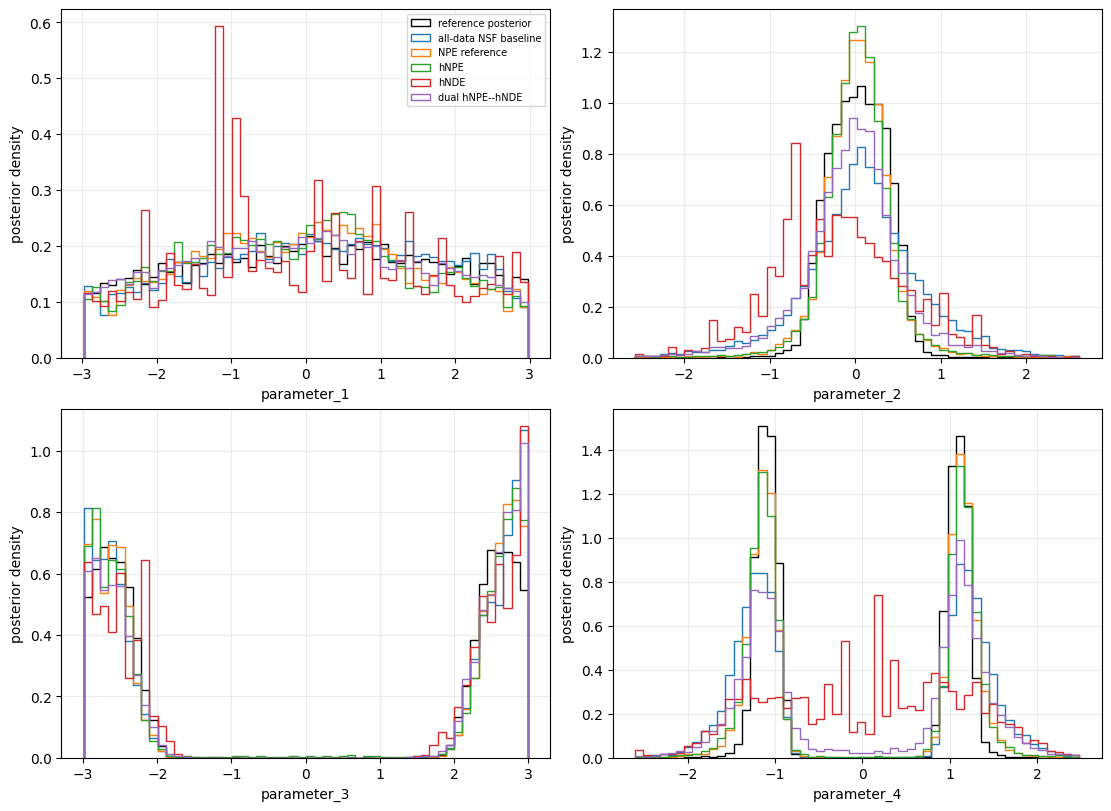

In [11]:
reference_samples = (
    task.get_reference_posterior_samples(num_observation=NUM_OBSERVATION)
    .detach().cpu().numpy()
)
parameter_labels = task.get_labels_parameters()

if task.dim_parameters == 2:
    methods = [
        "all-data NSF baseline",
        "NPE reference",
        "hNPE",
        "hNDE",
        "dual hNPE--hNDE",
    ]
    panels = [("reference posterior", reference_samples)] + [
        (method, posterior_draws.samples[method]) for method in methods
    ]
    n_columns = 3
    n_rows = int(np.ceil(len(panels) / n_columns))
    fig, axes = plt.subplots(
        n_rows, n_columns, figsize=(4.1 * n_columns, 3.8 * n_rows),
        squeeze=False, constrained_layout=True,
    )
    combined = np.concatenate([values for _, values in panels], axis=0)
    x_range = np.quantile(combined[:, 0], [0.002, 0.998])
    y_range = np.quantile(combined[:, 1], [0.002, 0.998])
    for ax, (title, values) in zip(axes.flat, panels):
        ax.hist2d(
            values[:, 0], values[:, 1], bins=65,
            range=[x_range, y_range], cmap="Blues", cmin=1,
        )
        ax.set(title=title, xlabel=parameter_labels[0], ylabel=parameter_labels[1])
    for ax in axes.flat[len(panels):]:
        ax.set_visible(False)
else:
    n_dimensions = min(4, task.dim_parameters)
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
    for dimension, ax in enumerate(axes.flat[:n_dimensions]):
        combined = np.concatenate(
            [
                reference_samples[:, dimension],
                posterior_draws.samples["all-data NSF baseline"][:, dimension],
                posterior_draws.samples["hNPE"][:, dimension],
                posterior_draws.samples["hNDE"][:, dimension],
            ]
        )
        low, high = np.quantile(combined, [0.002, 0.998])
        bins = np.linspace(low, high, 55)
        ax.hist(
            reference_samples[:, dimension], bins=bins, density=True,
            histtype="step", color="black", lw=2, label="reference posterior",
        )
        for method, style in [
            ("all-data NSF baseline", "--"),
            ("NPE reference", ":"),
            ("hNPE", "-"),
            ("hNDE", "-."),
            ("dual hNPE--hNDE", "-"),
        ]:
            ax.hist(
                posterior_draws.samples[method][:, dimension],
                bins=bins, density=True, histtype="step",
                lw=1.5, ls=style, label=method,
            )
        ax.set(xlabel=parameter_labels[dimension], ylabel="posterior density")
        ax.grid(alpha=0.25)
    axes.flat[0].legend(fontsize=7)

export_exercise10_figure(fig, "observation1_posterior_closure_v2")
plt.show()


### Optional posterior-predictive check

A posterior-predictive check needs fresh simulator calls. It is therefore disabled by default and is never folded into the official 100,000-call benchmark result. If enabled, the cell reports the extra call count explicitly and must be treated as a separate diagnostic campaign.


In [12]:
if RUN_POSTERIOR_PREDICTIVE:
    predictive_diagnostics = posterior_predictive_diagnostics(
        task,
        posterior_draws.samples[HEADLINE_METHOD],
        observation.detach().cpu().numpy(),
        n_simulations=2_000,
        seed=SEED + 800,
    )
    display(predictive_diagnostics.style.format(precision=4).hide(axis="index"))
    print("These 2,000 calls are diagnostic and are outside the official training budget.")
else:
    print(
        "Posterior-predictive simulation is disabled: the headline campaign "
        f"still uses exactly {NUM_SIMULATIONS:,} simulator calls."
    )


Posterior-predictive simulation is disabled: the headline campaign still uses exactly 100,000 simulator calls.


## 8. The paper comparison over all ten observations

A single observation is only a closure plot. The paper metric is the mean z-scored, five-fold C2ST over ten fixed observations. The already-trained amortized models are evaluated without retraining or hyperparameter changes.

The comparison contains every route: the all-data NSF baseline, the fivefold NPE reference, hNPE, hNDE, and the fixed geometric dual consensus. hNPE is the predeclared headline method, while hNDE and the dual result remain first-class diagnostics.


In [13]:
suite_results, _ = evaluate_observation_suite(
    hybrid_models,
    baseline_model=baseline_model,
    observations=OBSERVATIONS,
    n_proposal=N_PROPOSAL,
    n_samples=N_POSTERIOR_SAMPLES,
    seed=SEED + 900,
    keep_draws=False,
)
suite_results["profile"] = PROFILE
suite_results["run_tag"] = RUN_TAG
suite_results["flow_architecture"] = "lu_mixed_nsf_v2"

result_path = RESULT_DIR / f"{TASK_NAME}_{RUN_TAG}_c2st.csv"
suite_results.to_csv(result_path, index=False)
print("Saved:", result_path)
display(
    summarize_our_results(suite_results)
    .style.format({"mean": "{:.4f}", "std": "{:.4f}", "ci95": "{:.4f}"})
    .hide(axis="index")
)



Evaluating official observation 1

Evaluating official observation 2

Evaluating official observation 3

Evaluating official observation 4

Evaluating official observation 5

Evaluating official observation 6

Evaluating official observation 7

Evaluating official observation 8

Evaluating official observation 9

Evaluating official observation 10
Saved: exercise10_benchmark_results/slcp_challenge_budget100000_lu8_k5_ratioensemble4_v2_c2st.csv


task,num_simulations,algorithm,mean,std,count,ci95
slcp,100000,NPE reference,0.7135,0.0550,10,0.0341
slcp,100000,hNPE,0.7138,0.0552,10,0.0342
slcp,100000,dual hNPE--hNDE,0.7789,0.0600,10,0.0372
slcp,100000,all-data NSF baseline,0.8133,0.0481,10,0.0298
slcp,100000,hNDE,0.9084,0.0513,10,0.0318


Wrote standalone figure script: exercise10_figures_scripts/slcp/challenge_budget100000_lu8_k5_ratioensemble4_v2/paper_leaderboard_v2.py


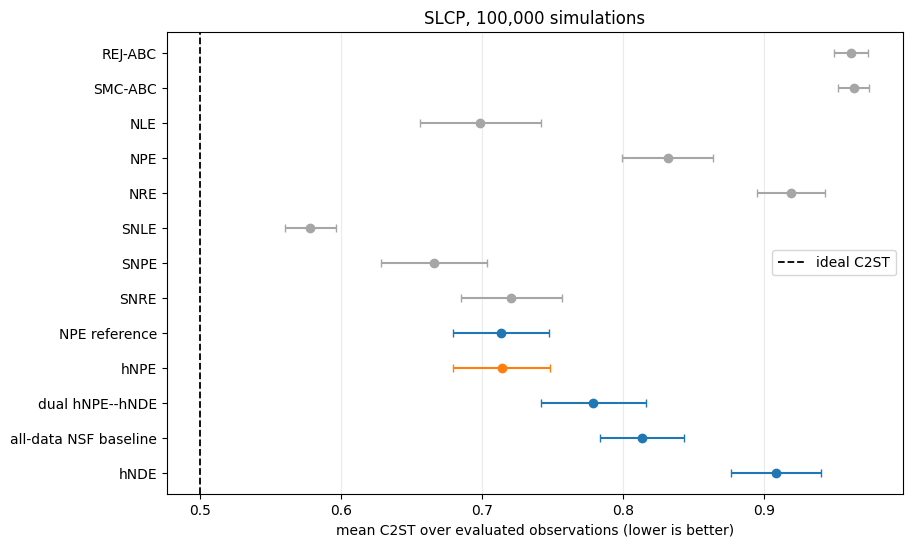

task,num_simulations,algorithm,mean,std,count,ci95,best_published_algorithm,best_published_mean,best_published_ci95,delta_C2ST,beats_published_mean
slcp,100000,hNPE,0.7138,0.0552,10,0.0342,SNLE,0.5781,0.0182,0.1356,False


The best published mean has not yet been beaten on this task.


In [14]:
paper_task = summarize_paper_results(
    paper_results,
    num_simulations=NUM_SIMULATIONS,
    task=TASK_NAME,
)
ours_task = summarize_our_results(suite_results)

fig, ax = plt.subplots(figsize=(9.5, 6.0))
paper_order = list(PAPER_ALGORITHMS)
paper_plot = paper_task.set_index("algorithm").reindex(paper_order).dropna().reset_index()
our_plot = ours_task.sort_values("mean")
labels = list(paper_plot["algorithm"]) + list(our_plot["algorithm"])
means = np.concatenate([paper_plot["mean"], our_plot["mean"]])
errors = np.concatenate([paper_plot["ci95"], our_plot["ci95"].fillna(0.0)])
colors = ["0.65"] * len(paper_plot) + [
    "C1" if algorithm == HEADLINE_METHOD else "C0"
    for algorithm in our_plot["algorithm"]
]
y = np.arange(len(labels))
for yi, mean, error, color in zip(y, means, errors, colors):
    ax.errorbar(mean, yi, xerr=error, fmt="o", color=color, capsize=3)
ax.axvline(0.5, color="black", ls="--", lw=1.3, label="ideal C2ST")
ax.set(
    yticks=y,
    yticklabels=labels,
    xlabel="mean C2ST over evaluated observations (lower is better)",
    title=f"{task.name_display}, {NUM_SIMULATIONS:,} simulations",
)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.25)
ax.legend()
export_exercise10_figure(fig, "paper_leaderboard_v2")
plt.show()

comparison = compare_with_paper(
    suite_results,
    paper_results,
    num_simulations=NUM_SIMULATIONS,
    headline_method=HEADLINE_METHOD,
)
display(comparison.style.format(precision=4).hide(axis="index"))

if len(OBSERVATIONS) < 10:
    print(
        "Diagnostic only: the paper averages over ten observations. "
        "Use PROFILE='paper' or 'challenge' for a headline comparison."
    )
elif bool(comparison["beats_published_mean"].iloc[0]):
    print("The predeclared hNPE headline beats the best published mean C2ST.")
else:
    print("The best published mean has not yet been beaten on this task.")


## 9. Two-task campaign: Two Moons and SLCP

Each task is trained and cached separately because the fivefold dual campaign is expensive. Run this notebook once for Two Moons and once for SLCP. The cell below reads only v2 result files and never averages them with the earlier defective-flow run.

SLCP is intentionally subjected to the same large hNPE and hNDE ensembles. Its five-dimensional, four-mode posterior makes it a reach target, but also a much stronger test of whether the dual construction remains useful beyond the two-dimensional diagnostic.


In [15]:
saved_result_files = sorted(RESULT_DIR.glob("*_v2_c2st.csv"))
if saved_result_files:
    all_our_results = pd.concat(
        [pd.read_csv(path) for path in saved_result_files],
        ignore_index=True,
    )
    all_our_results = all_our_results.loc[
        all_our_results["task"].isin(BENCHMARK_TASKS)
        & (all_our_results["run_tag"] == RUN_TAG)
    ]
    campaign_summary = summarize_our_results(all_our_results)
    display(
        campaign_summary.style.format(
            {"mean": "{:.4f}", "std": "{:.4f}", "ci95": "{:.4f}"}
        ).hide(axis="index")
    )
    completed_tasks = set(all_our_results["task"])
    missing_tasks = [name for name in BENCHMARK_TASKS if name not in completed_tasks]
    print("Loaded", len(saved_result_files), "v2 campaign file(s).")
    if missing_tasks:
        print("Still to run:", ", ".join(missing_tasks))
    else:
        print("Both Two Moons and SLCP v2 campaigns are complete.")
else:
    print("No v2 Exercise 10 result files were found yet.")


task,num_simulations,algorithm,mean,std,count,ci95
slcp,100000,NPE reference,0.7135,0.0550,10,0.0341
slcp,100000,hNPE,0.7138,0.0552,10,0.0342
slcp,100000,dual hNPE--hNDE,0.7789,0.0600,10,0.0372
slcp,100000,all-data NSF baseline,0.8133,0.0481,10,0.0298
slcp,100000,hNDE,0.9084,0.0513,10,0.0318
two_moons,100000,NPE reference,0.5096,0.0124,10,0.0077
two_moons,100000,hNPE,0.5096,0.0116,10,0.0072
two_moons,100000,dual hNPE--hNDE,0.5203,0.0210,10,0.0130
two_moons,100000,all-data NSF baseline,0.5497,0.0366,10,0.0227
two_moons,100000,hNDE,0.5886,0.0826,10,0.0512


Loaded 2 v2 campaign file(s).
Both Two Moons and SLCP v2 campaigns are complete.


## Conclusions and limitations

This v2 notebook implements the high-precision amortized strategy without modifying Exercises 1–9:

- learned LU mixing removes the two-dimensional coupling/permutation cancellation;
- a small all-data NSF shows how much of the gain comes from the repaired base estimator;
- five complementary folds use every simulation once for correction and four times for flow training;
- each fold retains a 1024-wide, five-layer, four-member correction ensemble;
- the hNDE likelihood path receives the same flow repair, network size, ensembling, and proposal statistics as hNPE;
- the ratio schedule decays on validation plateaus and never below (10^{-6});
- fresh v2 checkpoint tags prevent reuse of defective models;
- NLL, BCE, normalization, SBC, ESS, and optional posterior-predictive diagnostics are separated from the official reference-posterior C2ST;
- Two Moons and SLCP are both explicit benchmark targets.

Only one residual ratio is applied per fold. Iterative ratio boosting would require a newly distilled proposal and a new independent correction problem; multiplying several estimates of the same ratio is not used.

The 100,000-simulation result remains an amortized comparison. It does not yet add observation-specific sequential simulation rounds, so it should be compared most directly with one-round NPE/NRE/NLE. Beating sequential SNPE would require a separate, explicitly sequential budget allocation rather than silently changing this benchmark.
